In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, Conv2D, MaxPooling2D, InputLayer
from tensorflow.keras.optimizers import SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import ssl


ssl._create_default_https_context = ssl._create_unverified_context


output_dir = "/Users/yuezhiluo/Downloads/processed_data"
mel_spectrograms = []
labels = []

# Load mel spectrograms and labels
for category in ["happy", "fear", "disgust", "anger", "neutral", "sad"]:
    data = np.load(f"{output_dir}/{category}.npy", allow_pickle=True)
    mel_spectrograms.append(data)
    labels.extend([category] * len(data))

# Concatenate all category arrays into a single array
mel_spectrograms = np.concatenate(mel_spectrograms, axis=0)
labels = np.array(labels)

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(mel_spectrograms, categorical_labels, test_size=0.2, random_state=42)

# Reshape data for ResNet50 input
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]
X_train = np.repeat(X_train, 3, axis=-1)  # Repeat channel to convert (128, 216, 1) -> (128, 216, 3)
X_test = np.repeat(X_test, 3, axis=-1)

# Define the ResNet50 model using transfer learning
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, X_train.shape[2], 3))

# Freeze some layers of ResNet50 to allow partial retraining
for layer in base_model.layers[:140]:
    layer.trainable = False
for layer in base_model.layers[140:]:
    layer.trainable = True

# Build the final model
model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(1024, activation='relu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(y_train.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

# Learning rate scheduler
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test), callbacks=[reduce_lr])

# Evaluate the model
evaluation = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {evaluation[1] * 100:.2f}%")



Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.2914 - loss: 22.6036 - val_accuracy: 0.4650 - val_loss: 21.6441 - learning_rate: 0.0010
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.5292 - loss: 21.1363 - val_accuracy: 0.5700 - val_loss: 20.4466 - learning_rate: 0.0010
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.5758 - loss: 20.3709 - val_accuracy: 0.5817 - val_loss: 20.0059 - learning_rate: 0.0010
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.6601 - loss: 19.5775 - val_accuracy: 0.6200 - val_loss: 19.3310 - learning_rate: 0.0010
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.7345 - loss: 18.8658 - val_accuracy: 0.6200 - val_loss: 18.8297 - learning_rate: 0.0010
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 570ms/step - accuracy: 0.6630 - loss: 18.7482
Test Accuracy: 62.00%


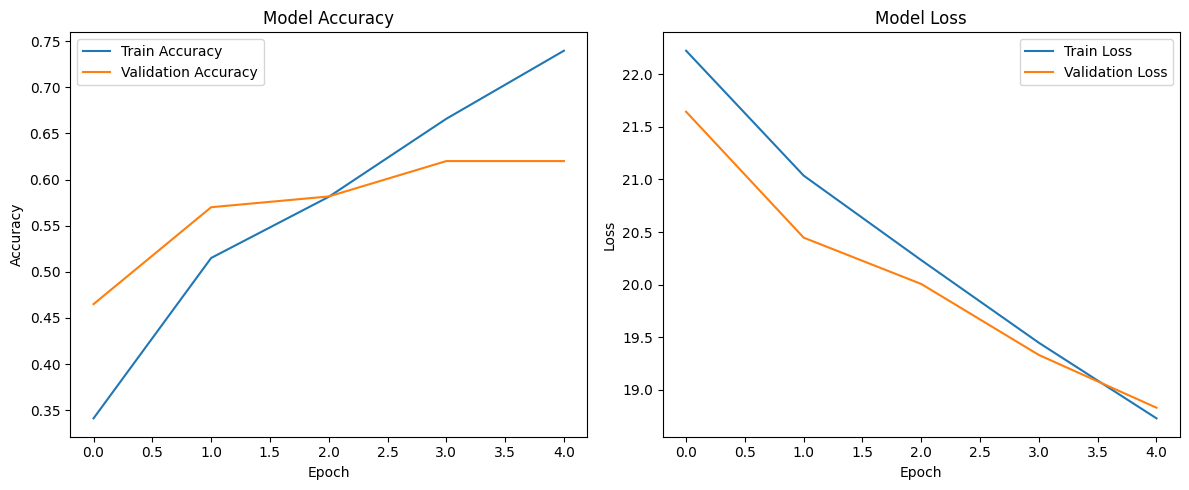

In [10]:
import ssl
import matplotlib.pyplot as plt
# Plot accuracy and loss
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step


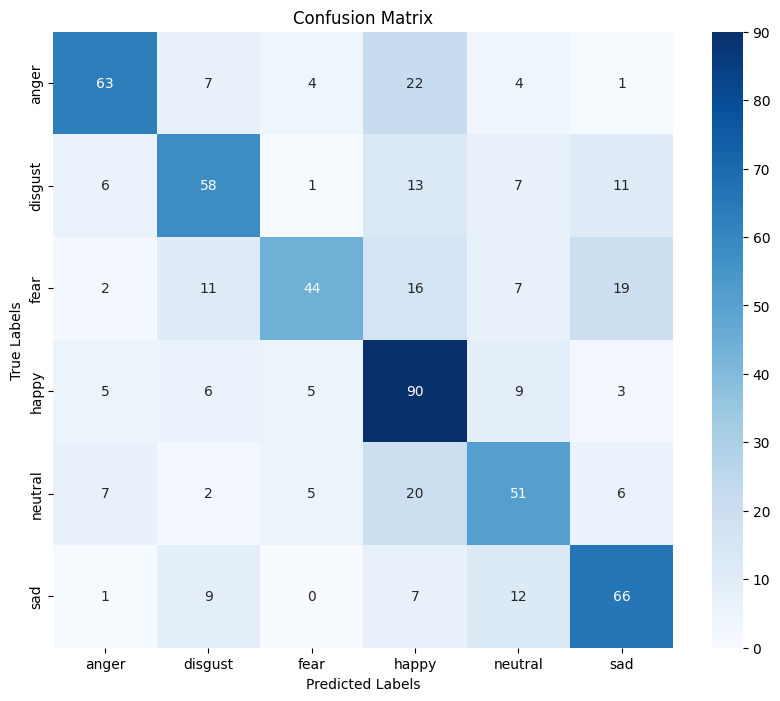

              precision    recall  f1-score   support

       anger       0.75      0.62      0.68       101
     disgust       0.62      0.60      0.61        96
        fear       0.75      0.44      0.56        99
       happy       0.54      0.76      0.63       118
     neutral       0.57      0.56      0.56        91
         sad       0.62      0.69      0.66        95

    accuracy                           0.62       600
   macro avg       0.64      0.62      0.62       600
weighted avg       0.64      0.62      0.62       600



In [25]:
import numpy as np
import tensorflow as tf
!pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt


y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Create confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_)
print(report)
